# DATE2 实验5：预取敏感性与映射—预取协同优化

在MoDSE上扫描8个Prefetch Window与4个Weight Chunk粒度，共32组配置。

本实验依次验证：
1. 只增加预取可能因过早占用、传输不及时或干扰而恶化性能；
2. 动态映射能否缓解固定预取的敏感性；
3. 最终MemDomain联合方案能否严格优于最强单独优化候选。

实验4已单独验证无预取条件下的动态映射收益，本实验不再重复跨模型结论。


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scalesim.memory.memdomain_experiment import workload_digest
ROOT=Path.cwd().resolve().parent if Path.cwd().name=='fig' else Path.cwd().resolve()
OUT=ROOT/'outputs/DATE2';FIG=ROOT/'fig/DATE2';FIG.mkdir(parents=True,exist_ok=True)
PUBLIC=['Static-NoPF','Static-NaivePF','Dynamic-NoPF','Dynamic-NaivePF','MemDomain']
FINAL_INTERNAL='MemDomain-'+'Safe'
def public_rows(frame):
    q=frame[frame.baseline.isin(['Static-NoPF','Static-NaivePF','Dynamic-NoPF',
                                 'Dynamic-NaivePF',FINAL_INTERNAL])].copy()
    q['baseline']=q.baseline.replace({FINAL_INTERNAL:'MemDomain'})
    assert set(q.baseline)==set(PUBLIC)
    return q
def current_matrix(suite,stem):
    config=ROOT/'configs/MoE/DATE2'/suite/f'{stem}.json'
    output=OUT/suite/f'{stem}.csv'
    assert config.exists(),config
    assert output.exists(),f'Missing output: {output}'
    frame=pd.read_csv(output)
    expected=workload_digest(json.loads(config.read_text(encoding='utf-8')))
    assert set(frame.workload_hash)=={expected},f'Stale output: {output}'
    return frame

rows=[]
adaptive_flags=[]
for config in sorted((ROOT/'configs/MoE/DATE2/joint_prefetch').glob('w*_c*.json')):
    w,c=map(int,re.search(r'w(\d+)_c(\d+)',config.stem).groups())
    payload=json.loads(config.read_text(encoding='utf-8'))
    adaptive_flags.append(bool(payload['policy'].get('adaptive_prefetch',False)))
    q=current_matrix('joint_prefetch',config.stem).copy()
    q['baseline']=q.baseline.replace({FINAL_INTERNAL:'MemDomain'})
    q['window']=w;q['chunk_tiles']=c;rows.append(q)
d=pd.concat(rows,ignore_index=True)
assert len(d)==32*7
assert sorted(d.window.unique())==[0,1,2,4,8,16,32,64]
assert sorted(d.chunk_tiles.unique())==[1,2,4,8]
assert len(adaptive_flags)==32
print('Current adaptive_prefetch configurations:',sum(adaptive_flags),'/ 32')


Current adaptive_prefetch configurations: 32 / 32


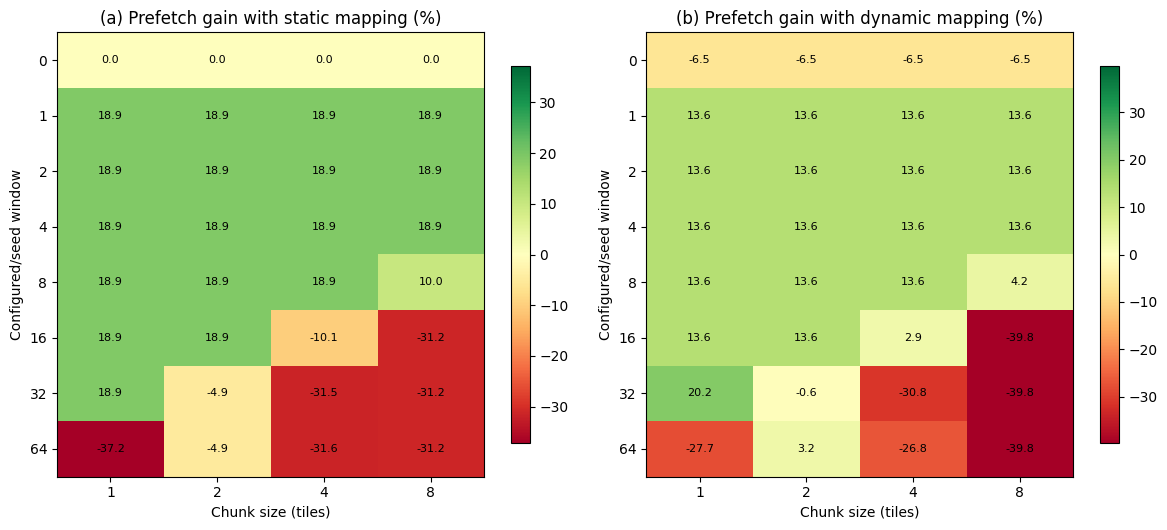

Static prefetch harmful configurations: 9 / 32
Dynamic prefetch harmful configurations: 11 / 32


In [2]:
def grid(name,metric='total_cycles'):
    return d[d.baseline.eq(name)].pivot(
        index='window',columns='chunk_tiles',values=metric).sort_index().sort_index(axis=1)
def heat(ax,data,title,cmap='RdYlGn',center=None,fmt='.1f'):
    if center is None:
        im=ax.imshow(data,aspect='auto',cmap=cmap)
    else:
        from matplotlib.colors import TwoSlopeNorm
        bound=max(abs(float(np.nanmin(data))),abs(float(np.nanmax(data))),1e-9)
        im=ax.imshow(data,aspect='auto',cmap=cmap,
                     norm=TwoSlopeNorm(vmin=-bound,vcenter=center,vmax=bound))
    ax.set_xticks(range(len(data.columns)),data.columns)
    ax.set_yticks(range(len(data.index)),data.index)
    ax.set_xlabel('Chunk size (tiles)');ax.set_ylabel('Configured/seed window')
    ax.set_title(title)
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            ax.text(j,i,format(data.iloc[i,j],fmt),ha='center',va='center',fontsize=8)
    plt.colorbar(im,ax=ax,shrink=.85)

static_pf_gain=(1-grid('Static-NaivePF')/grid('Static-NoPF'))*100
dynamic_pf_gain=(1-grid('Dynamic-NaivePF')/grid('Dynamic-NoPF'))*100
fig,axes=plt.subplots(1,2,figsize=(12,5.4))
heat(axes[0],static_pf_gain,'(a) Prefetch gain with static mapping (%)',
     cmap='RdYlGn',center=0)
heat(axes[1],dynamic_pf_gain,'(b) Prefetch gain with dynamic mapping (%)',
     cmap='RdYlGn',center=0)
plt.tight_layout();plt.savefig(FIG/'exp5_prefetch_tradeoff.pdf',bbox_inches='tight');plt.show()
print('Static prefetch harmful configurations:',int((static_pf_gain<0).sum().sum()),'/ 32')
print('Dynamic prefetch harmful configurations:',int((dynamic_pf_gain<0).sum().sum()),'/ 32')


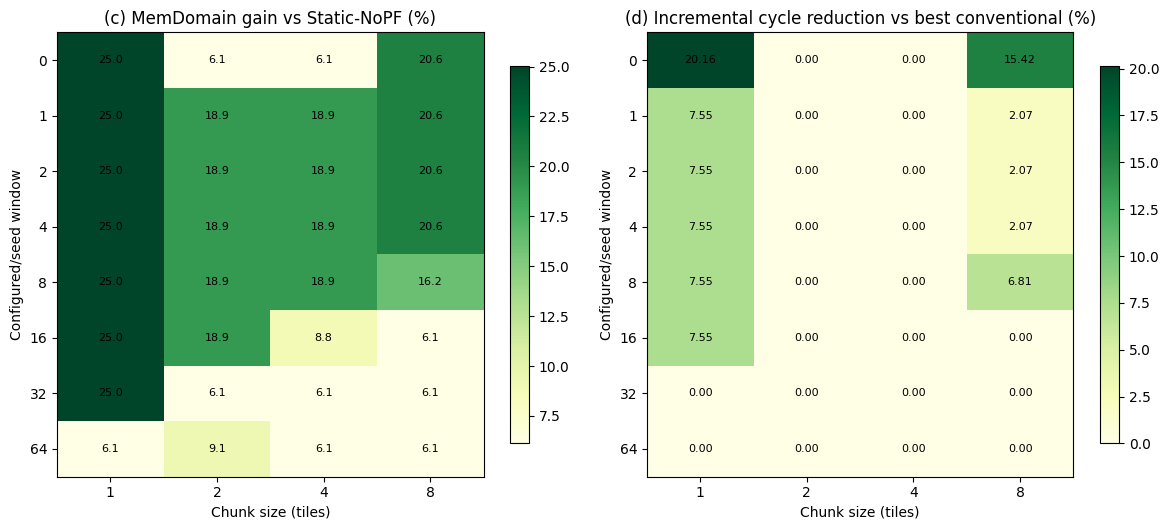

Non-regression contract: 32/32 PASS
Strict joint improvement: 11/32 configurations
Positive-case incremental gain: mean=7.85%, max=20.16%
Best joint point: configured window=0, chunk=1 tiles
Globally tuned best conventional: 91262 cycles
Globally tuned best MemDomain: 91262 cycles
Global-search incremental gain: 0.00%


In [3]:
conventional=['Static-NoPF','Static-NaivePF','Dynamic-NoPF','Dynamic-NaivePF']
wide=d[d.baseline.isin(conventional+['MemDomain'])].pivot(
    index=['window','chunk_tiles'],columns='baseline',values='total_cycles')
best_conventional=wide[conventional].min(axis=1)
final_gain=(1-wide.MemDomain/best_conventional)*100
final_grid=final_gain.unstack('chunk_tiles')
final_vs_static=(1-grid('MemDomain')/grid('Static-NoPF'))*100

fig,axes=plt.subplots(1,2,figsize=(12,5.4))
heat(axes[0],final_vs_static,'(c) MemDomain gain vs Static-NoPF (%)',
     cmap='YlGn',fmt='.1f')
heat(axes[1],final_grid,'(d) Incremental cycle reduction vs best conventional (%)',
     cmap='YlGn',fmt='.2f')
plt.tight_layout();plt.savefig(FIG/'exp5_public_sensitivity.pdf',bbox_inches='tight');plt.show()

contract=(wide.MemDomain<=best_conventional)
strict=final_gain>1e-12
assert contract.all(),'Final scheme regresses below an implementable incumbent'
print(f'Non-regression contract: {contract.sum()}/32 PASS')
print(f'Strict joint improvement: {strict.sum()}/32 configurations')
positive=final_gain[strict]
print(f'Positive-case incremental gain: mean={positive.mean():.2f}%, '
      f'max={positive.max():.2f}%')
best=positive.idxmax()
print(f'Best joint point: configured window={best[0]}, '
      f'chunk={best[1]} tiles')
global_conventional=int(wide[conventional].min().min())
global_memdomain=int(wide.MemDomain.min())
print(f'Globally tuned best conventional: {global_conventional} cycles')
print(f'Globally tuned best MemDomain: {global_memdomain} cycles')
print(f'Global-search incremental gain: '
      f'{(1-global_memdomain/global_conventional)*100:.2f}%')


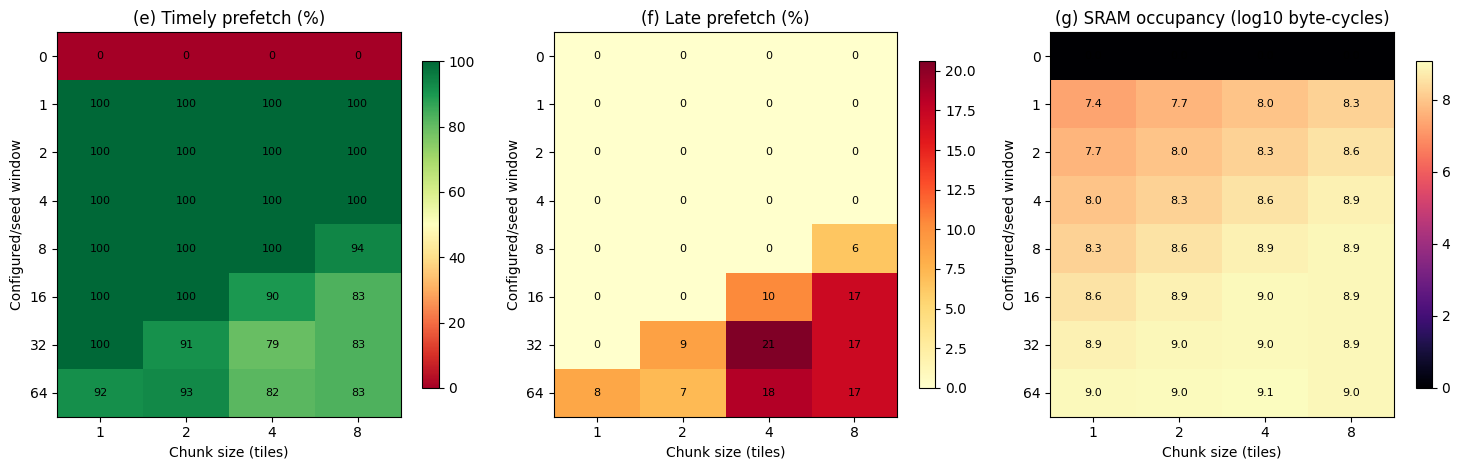

,count
static-prefetch harmful configs,9
dynamic-prefetch harmful configs,11
reported MemDomain strict wins,11
internal raw joint strict wins,11


adaptive_prefetch enabled: True


In [4]:
timely=grid('Dynamic-NaivePF','timely_prefetch_ratio')*100
late=grid('Dynamic-NaivePF','late_prefetch_ratio')*100
occupancy=np.log10(grid('Dynamic-NaivePF','prefetch_occupancy_byte_cycles')+1)
fig,axes=plt.subplots(1,3,figsize=(15,4.8))
heat(axes[0],timely,'(e) Timely prefetch (%)',cmap='RdYlGn',fmt='.0f')
heat(axes[1],late,'(f) Late prefetch (%)',cmap='YlOrRd',fmt='.0f')
heat(axes[2],occupancy,'(g) SRAM occupancy (log10 byte-cycles)',
     cmap='magma',fmt='.1f')
plt.tight_layout();plt.savefig(FIG/'exp5_prefetch_mechanisms.pdf',bbox_inches='tight');plt.show()

# Internal diagnostic only: Raw is not an additional paper scheme.
raw=d[d.baseline.eq('MemDomain-Raw')].set_index(['window','chunk_tiles']).total_cycles
raw_gain=(1-raw/best_conventional)*100
diagnostic=pd.DataFrame({
 'count':[
   int((static_pf_gain<0).sum().sum()),
   int((dynamic_pf_gain<0).sum().sum()),
   int(strict.sum()),
   int((raw_gain>1e-12).sum())],
},index=['static-prefetch harmful configs','dynamic-prefetch harmful configs',
         'reported MemDomain strict wins','internal raw joint strict wins'])
display(diagnostic)
print('adaptive_prefetch enabled:',sum(adaptive_flags)==32)
if not all(adaptive_flags):
    print('PAPER JOINT-OPTIMIZATION REQUIREMENT: NOT MET BY THIS RUN')


## 判读边界

- 红色负值区域证明固定预取并非总能获益，可用于支撑“只考虑预取存在问题”；
- `MemDomain vs best conventional`必须出现严格正值，才能证明协同优化带来额外收益；
- 当前配置若未启用`adaptive_prefetch`，最终MemDomain只是安全选择固定候选，不能称为在线协同优化；
- `MemDomain-Raw`只用于定位协同策略是否存在潜力，不作为论文报告的第二套方案。
